# WORD2VEC

In [1]:
from src.procesamiento_corpus.preprocesamiento import cargar_y_preparar_corpus
from src.modelos_analisis_semantico.word2vec import (
    entrenar_cbow_y_skipgram, palabras_similares, analogia,
    matriz_vectores_documentos, matriz_similitud_documentos, similitud_entre_grupos,
)

## CARGA DEL CORPUS

In [1]:
corpus = cargar_y_preparar_corpus()
corpus[["lugar", "categoria", "calificacion", "tokens"]].head()

NameError: name 'cargar_y_preparar_corpus' is not defined

## CBOW Y SKIP-GRAM

In [3]:
modelos = entrenar_cbow_y_skipgram(corpus["tokens"], epochs=15)

print(f"Vocabulario CBOW: {len(modelos['cbow'].wv)} palabras")
print(f"Vocabulario Skip-Gram: {len(modelos['skipgram'].wv)} palabras")


  [cbow] época 1/15 - pérdida promedio: 2.9500
  [cbow] época 2/15 - pérdida promedio: 2.3504
  [cbow] época 3/15 - pérdida promedio: 2.0283
  [cbow] época 4/15 - pérdida promedio: 1.7729
  [cbow] época 5/15 - pérdida promedio: 1.5636
  [cbow] época 6/15 - pérdida promedio: 1.3914
  [cbow] época 7/15 - pérdida promedio: 1.2644
  [cbow] época 8/15 - pérdida promedio: 1.1572
  [cbow] época 9/15 - pérdida promedio: 1.0877
  [cbow] época 10/15 - pérdida promedio: 1.0207
  [cbow] época 11/15 - pérdida promedio: 0.9554
  [cbow] época 12/15 - pérdida promedio: 0.9192
  [cbow] época 13/15 - pérdida promedio: 0.8785
  [cbow] época 14/15 - pérdida promedio: 0.8464
  [cbow] época 15/15 - pérdida promedio: 0.8145
  [skipgram] época 1/15 - pérdida promedio: 2.6308
  [skipgram] época 2/15 - pérdida promedio: 2.2814
  [skipgram] época 3/15 - pérdida promedio: 2.0984
  [skipgram] época 4/15 - pérdida promedio: 2.0020
  [skipgram] época 5/15 - pérdida promedio: 1.9505
  [skipgram] época 6/15 - pérdida 

In [4]:
palabras_de_interes = ["playa", "hotel", "servicio", "comida", "personal", "precio"]
"""
Ejemplos de palabras a relacionar
Pueden cambiarse por otras
"""
for nombre, modelo in modelos.items():
    print(f"\n=== {nombre.upper()} ===")
    for palabra in palabras_de_interes:
        print(f"Similares a '{palabra}': {palabras_similares(modelo, palabra, top_n=5)}")



=== CBOW ===
Similares a 'playa': [('cava', 0.4899700318703579), ('punta', 0.4764205805784294), ('comportamiento', 0.4472291645576387), ('soñar', 0.44302114249394664), ('pez', 0.44176651057439364)]
Similares a 'hotel': [('comidas', 0.38276305189691073), ('disgustar', 0.3812948102820249), ('profundamente', 0.37947279051605787), ('gimnasio', 0.35757323721615436), ('establecimiento', 0.35532008857053377)]
Similares a 'servicio': [('casado', 0.4410217908550246), ('atendio', 0.42890783123714943), ('pesimo', 0.4094964123276441), ('mainor', 0.4045078673872247), ('maduro', 0.4032289906390303)]
Similares a 'comida': [('sopa', 0.5029559440226644), ('batido', 0.4947876062044191), ('calma', 0.4841583106298175), ('costilla', 0.46028940276751407), ('bowl', 0.4601011334984441)]
Similares a 'personal': [('paula', 0.59749240122453), ('anfitriones', 0.498485055702827), ('mejorable', 0.4935348598105963), ('atendio', 0.48907495667837203), ('bienvenidar', 0.4690650208260348)]
Similares a 'precio': [('prom

In [6]:
# Analogías
print(analogia(modelos["skipgram"], positivos=["hotel", "playa"], negativos=["hotel"]))


[('blanca', 0.5377907467016824), ('arena', 0.5258857740233918), ('mar', 0.522676455885436), ('playas', 0.5073468900928525), ('compre', 0.4861472146535517)]


In [7]:
import pandas as pd

muestra = pd.concat([
    grupo.sample(min(5, len(grupo)), random_state=42)
    for _, grupo in corpus.groupby("categoria")
]).reset_index(drop=True)

print(f"Muestra: {len(muestra)} reseñas ({muestra['categoria'].value_counts().to_dict()})")

Muestra: 15 reseñas ({'alojamiento': 5, 'parque': 5, 'restaurante': 5})


## MATRIZ DE SIMILITUD

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

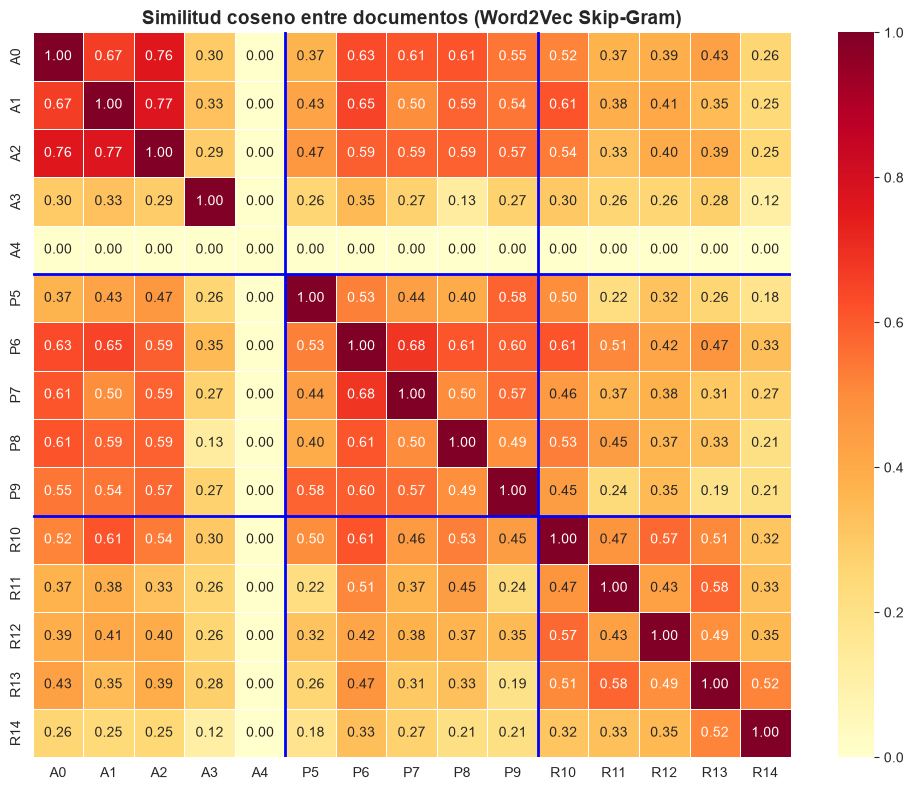

P=Parque, R=Restaurante, A=Alojamiento


In [14]:
sim_w2v = matriz_similitud_documentos(modelos["skipgram"], muestra["tokens"])

etiquetas = [f"{cat[0].upper()}{i}" for i, cat in enumerate(muestra["categoria"])]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_w2v, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Similitud coseno entre documentos (Word2Vec Skip-Gram)", fontsize=14, fontweight="bold")

# Líneas separando categorías (asume 5 por categoría, como arriba)
for pos in range(5, len(muestra), 5):
    ax.axhline(y=pos, color="blue", linewidth=2)
    ax.axvline(x=pos, color="blue", linewidth=2)

plt.tight_layout()
plt.show()

print("P=Parque, R=Restaurante, A=Alojamiento")

In [13]:
print(similitud_entre_grupos(modelos["skipgram"], corpus["tokens"], corpus["categoria"]))

{('alojamiento', 'parque'): np.float64(0.848198187152286), ('alojamiento', 'restaurante'): np.float64(0.840677174706372), ('parque', 'restaurante'): np.float32(0.7991939)}
